In [2]:
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_debug_nans", True)
print(jax.local_devices()[0].device_kind)
from jax import numpy as np, random as jr, tree as jtu
import os


from zodiax.optimisation import sgd, adam

import amigo
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


In [3]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/WR137/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/WR137/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/WR137/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [4]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # badpix = np.array(file["BADPIX"].data, dtype=bool)
    # im = np.array(file["SLOPE"].data.sum(0))
    # im = np.where(badpix, np.nan, im)
    # mask = binary_dilation(im == np.nanmax(im), iterations=2)
    # file["BADPIX"].data += mask.astype(int)

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

In [5]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}'
    )

    t0 = t

# h


------------------------------

WR137 F480M, Dither 1/4, Roll 192.0deg, 2.0min, 2022-07-13 11:42:10.194
WR137 F480M, Dither 2/4, Roll 192.0deg, 2.0min, 2022-07-13 11:46:01.618
WR137 F480M, Dither 3/4, Roll 192.0deg, 2.0min, 2022-07-13 11:49:54.065
WR137 F480M, Dither 4/4, Roll 192.0deg, 2.0min, 2022-07-13 11:53:45.553

------------------------------

HD 228337 F480M, Dither 1/1, Roll 189.5deg, 9.0min, 2022-07-15 11:42:00.230
WR137 F480M, Dither 1/4, Roll 189.8deg, 8.0min, 2022-07-15 12:38:42.741

------------------------------

WR137 F480M, Dither 1/4, Roll 162.7deg, 2.0min, 2022-08-08 18:44:08.571
WR137 F480M, Dither 2/4, Roll 162.7deg, 2.0min, 2022-08-08 18:47:59.995
WR137 F480M, Dither 3/4, Roll 162.7deg, 2.0min, 2022-08-08 18:51:51.419
WR137 F480M, Dither 4/4, Roll 162.7deg, 2.0min, 2022-08-08 18:55:42.843
HD 228337 F480M, Dither 1/4, Roll 162.0deg, 2.2min, 2022-08-08 19:49:27.954
HD 228337 F480M, Dither 2/4, Roll 162.0deg, 2.2min, 2022-08-08 19:53:19.378
HD 228337 F480M, Dither 3

/home/max/miniforge3/envs/ami/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [6]:
class DitherAbVisFit(amigo.model_fits.SplineVisFit):

    date: str  # isot
    month: str

    def __init__(self, file, joint_fit=False):
        expmid = Time(file[0].header["EXPMID"], format="mjd")
        self.date = str(expmid.isot)
        self.month = f"{expmid.ymdhms[1]:02d}"
        super().__init__(file, joint_fit=joint_fit)

    def get_key(self, param):
        # Return the per exposure key if not joint fitting
        match param:
            case "aberrations":

                dither = "S" if self.month == "07" else self.dither

                return "_".join(
                    [
                        self.program,
                        self.filter,
                        dither,
                        self.month,
                    ]
                )

        return super().get_key(param)

    def print_summary(self):
        print(
            # f"File {self.key}\n"
            f"Star {self.star}\n"
            f"Filter {self.filter}\n"
            f"Parang {self.parang:.2f} deg\n"
            f"Dither {self.dither}\n"
            f"Date {self.date}\n"
            # f"nints {self.nints}\n"
            # f"ngroups {len(self.slopes)+1}\n"
        )


import dLux as dl
from dLux import utils as dlu
from amigo.misc import interp


class WheelVisFit(amigo.model_fits.SplineVisFit):

    date: str  # isot
    month: str

    def __init__(self, file, joint_fit=False):
        expmid = Time(file[0].header["EXPMID"], format="mjd")
        self.date = str(expmid.isot)
        self.month = f"{expmid.ymdhms[1]:02d}"
        super().__init__(file, joint_fit=joint_fit)

    def get_key(self, param):

        match param:
            case "wheel_rot":
                return "_".join(
                    [
                        self.program,
                        self.month,
                    ]
                )

        return super().get_key(param)

    def map_param(self, param):

        # Map the appropriate parameter to the correct key
        if param in ["wheel_rot"]:
            return f"{param}.{self.get_key(param)}"

        return super().map_param(param)

    def initialise_params(self, optics, vis_model=None, one_on_fs_order=1):
        params = super().initialise_params(
            optics, vis_model=vis_model, one_on_fs_order=one_on_fs_order
        )
        params["wheel_rot"] = (self.get_key("wheel_rot"), np.array(0.0))
        return params

    def rotate(self, image, angle, clip=True):
        """
        Rotate the distribution by the parallactic angle.
        This method rotates the distribution using the dLux utility functions.
        Args:
            distribution: The distribution of the resolved source.
            angle: The angle in degrees by which to rotate the distribution.
            clip: If True, clips the distribution to enforce positivity.
        Returns:
            Array: The rotated distribution, optionally clipped to enforce positivity.
        """
        knots = dlu.pixel_coords(image.shape[0], 1.0)
        samps = dlu.rotate_coords(knots, dlu.deg2rad(angle))

        image = interp(
            image,
            knots,
            samps,
            method="cubic",
        )

        # clipping to enforce positivity
        if clip:
            return np.clip(image, min=0.0, max=None)

        return image

    def model_psf(self, model):
        wfs = self.model_wfs(model)
        image = wfs.psf.sum(0)
        pscale = wfs.pixel_scale.mean(0)

        angle = model.params["wheel_rot"][self.get_key("wheel_rot")]
        image = self.rotate(image, angle)

        return dl.PSF(image, pscale)

In [7]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()
state = load_dict(cache + "calibration.npy")
state["wheel_rot"] = np.array(0.0)  # degrees

cal_exposures = [amigo.model_fits.SplineVisFit(file) for file in cal_files]
sci_exposures = [amigo.model_fits.SplineVisFit(file) for file in sci_files]
# exposures = cal_exposures[0:1]  # + sci_exposures
# exposures = cal_exposures[0:3] + [sci_exposures[i] for i in [0, 1, 4, 5, 6]]
# exposures = [cal_exposures[i] for i in [0, 2]]
exposures = cal_exposures[0:1] + sci_exposures[4:5]

model = amigo.core_models.AmigoModel(
    exposures,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    vis_model=amigo.vis_models.LogVisModel(
        load_dict(cache + "vis_basis.npy"), n_basis=420
    ),
    state=state,
)

01349_F480M
File 01349_005_02_03_1
Star HD 228337
Filter F480M
nints 1020
ngroups 7



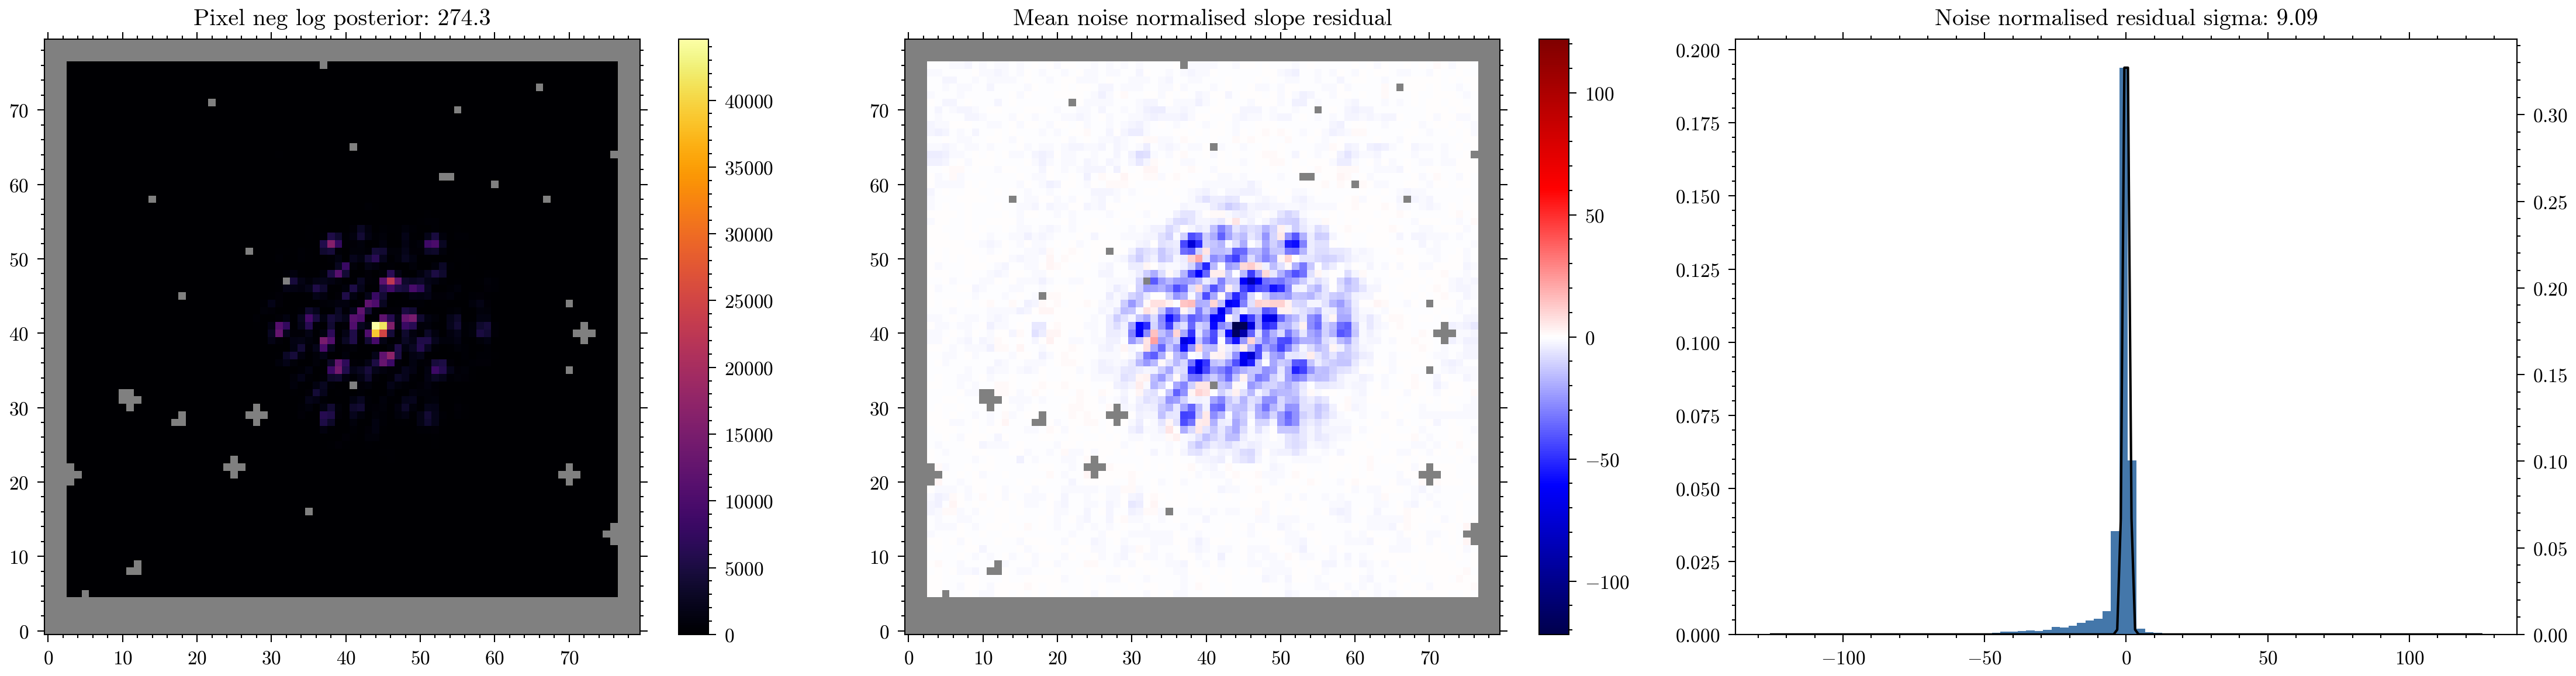

01349_F480M
File 01349_006_02_03_1
Star WR137
Filter F480M
nints 1600
ngroups 4



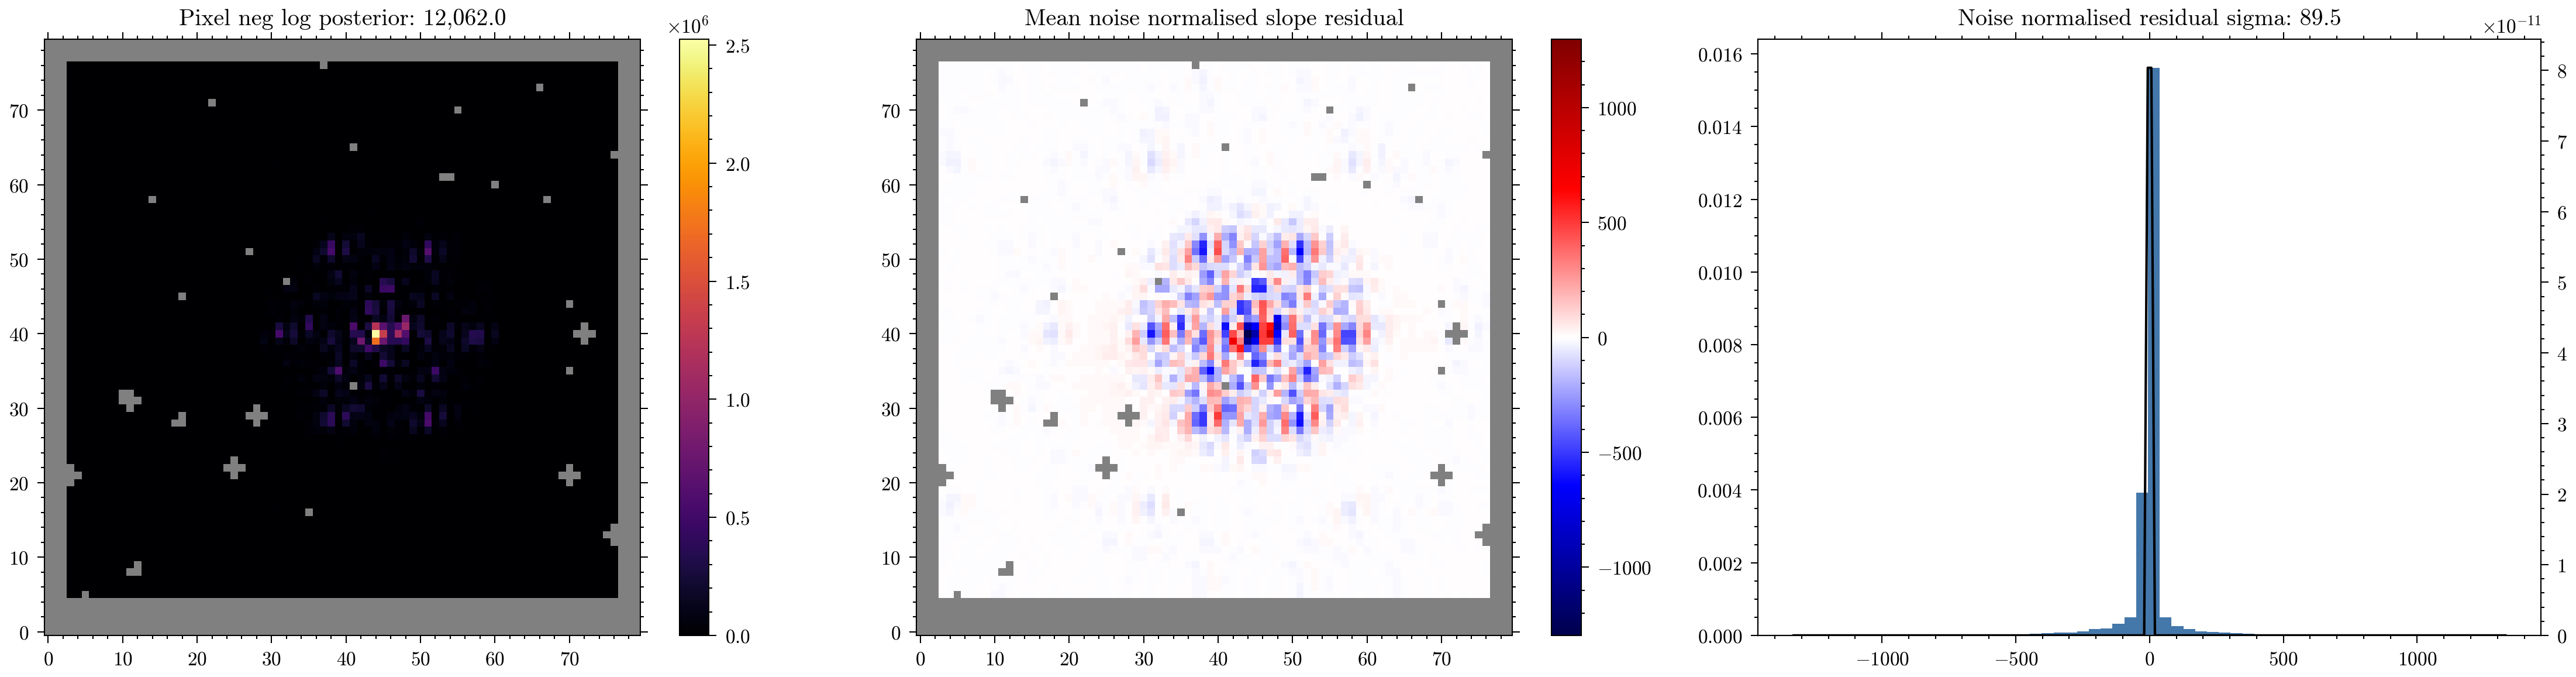

In [8]:
for exp in exposures:
    print(exp.get_key("aberrations"))
    exp.print_summary()
    amigo.plotting.summarise_fit(model, exp, residuals=False)

In [12]:
n_epoch = 200

config = {
    "positions": sgd(2e-1, 0),
    "fluxes": sgd(2e-1, 0),
    "aberrations": sgd(3e-2, 4),
    "spectra": sgd(2e-1, 10),
    "phases": sgd(2e0, 20),
    "amplitudes": sgd(2e0, 20),
    # "wheel_rot": sgd(1e-1, 50),
}

trainer = amigo.fitting.Trainer(
    cache=os.path.join(amigo_cache, "fishers/"),
)

trainer = trainer.populate_fishers(
    # model.set("detector.ramp.bleed", False).set("params", params),
    model,
    exposures,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=list(config.keys()),
)

# trainer = trainer.update_fishers(
#     model,
#     exposures,
#     parameters=["wheel_rot"],
# )

print("Number of exposures: ", len(exposures))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    # batches=amigo.fitting.batch_exposures(exposures, n_batch=15),
    # batches=amigo.fitting.batch_exposures(exposures, n_batch=len(exposures) // 3),
    batches=exposures,
)

Number of exposures:  2


  0%|          | 0/200 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 6,169.17
Estimated run time: 0:01:25
Full Time: 0:01:49
Final Loss: 35.38


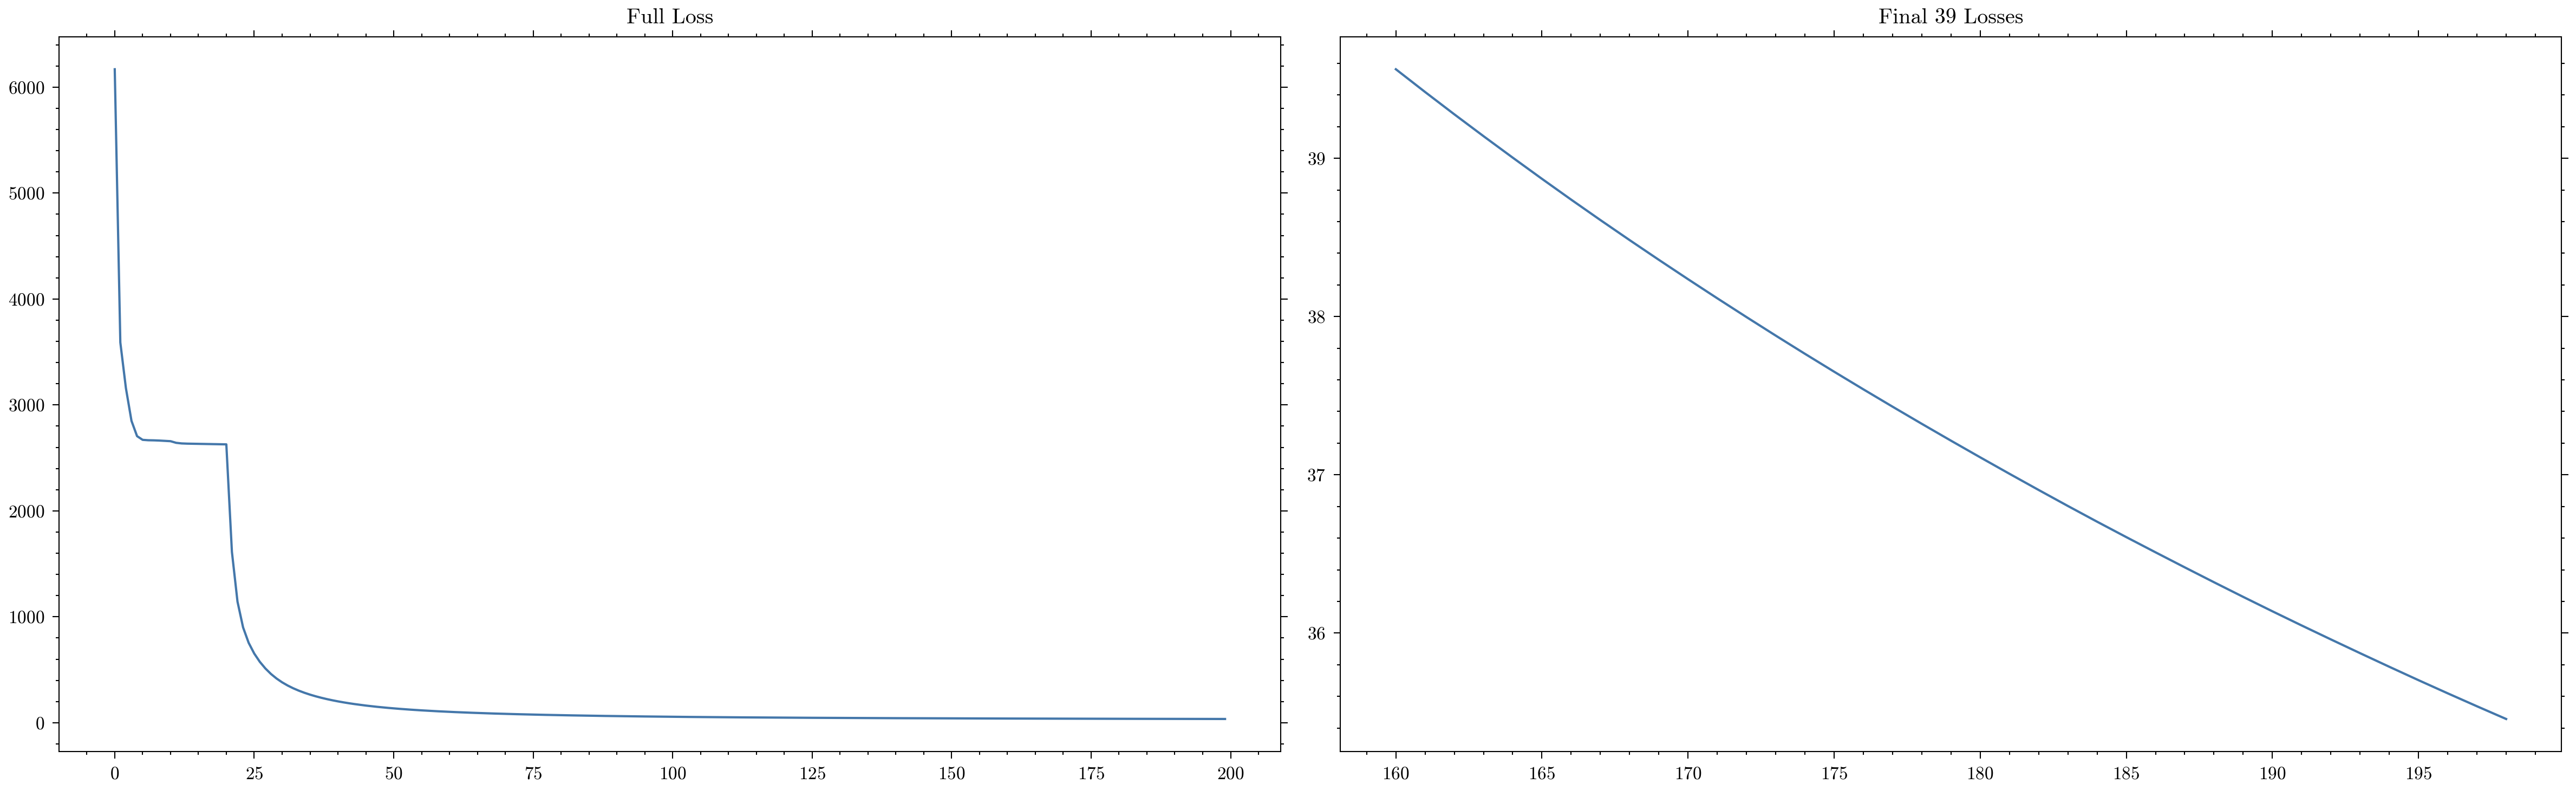

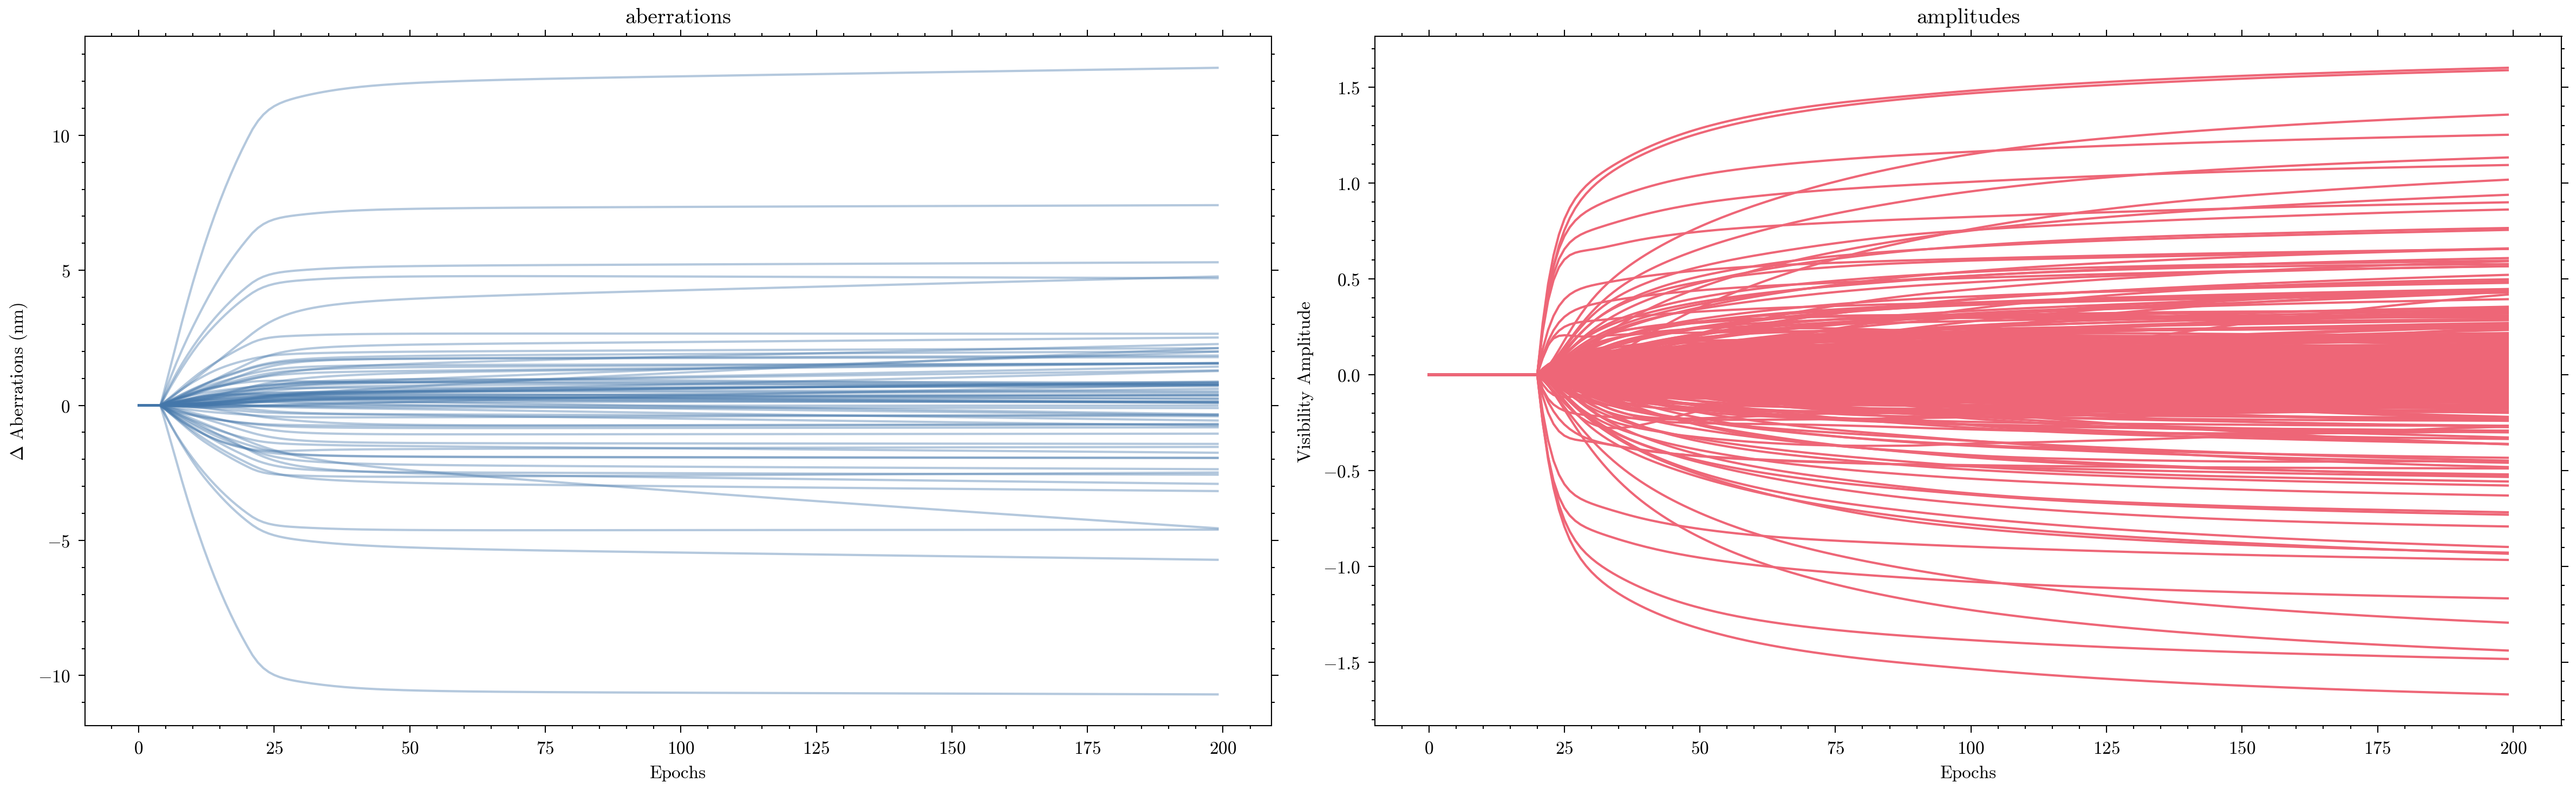

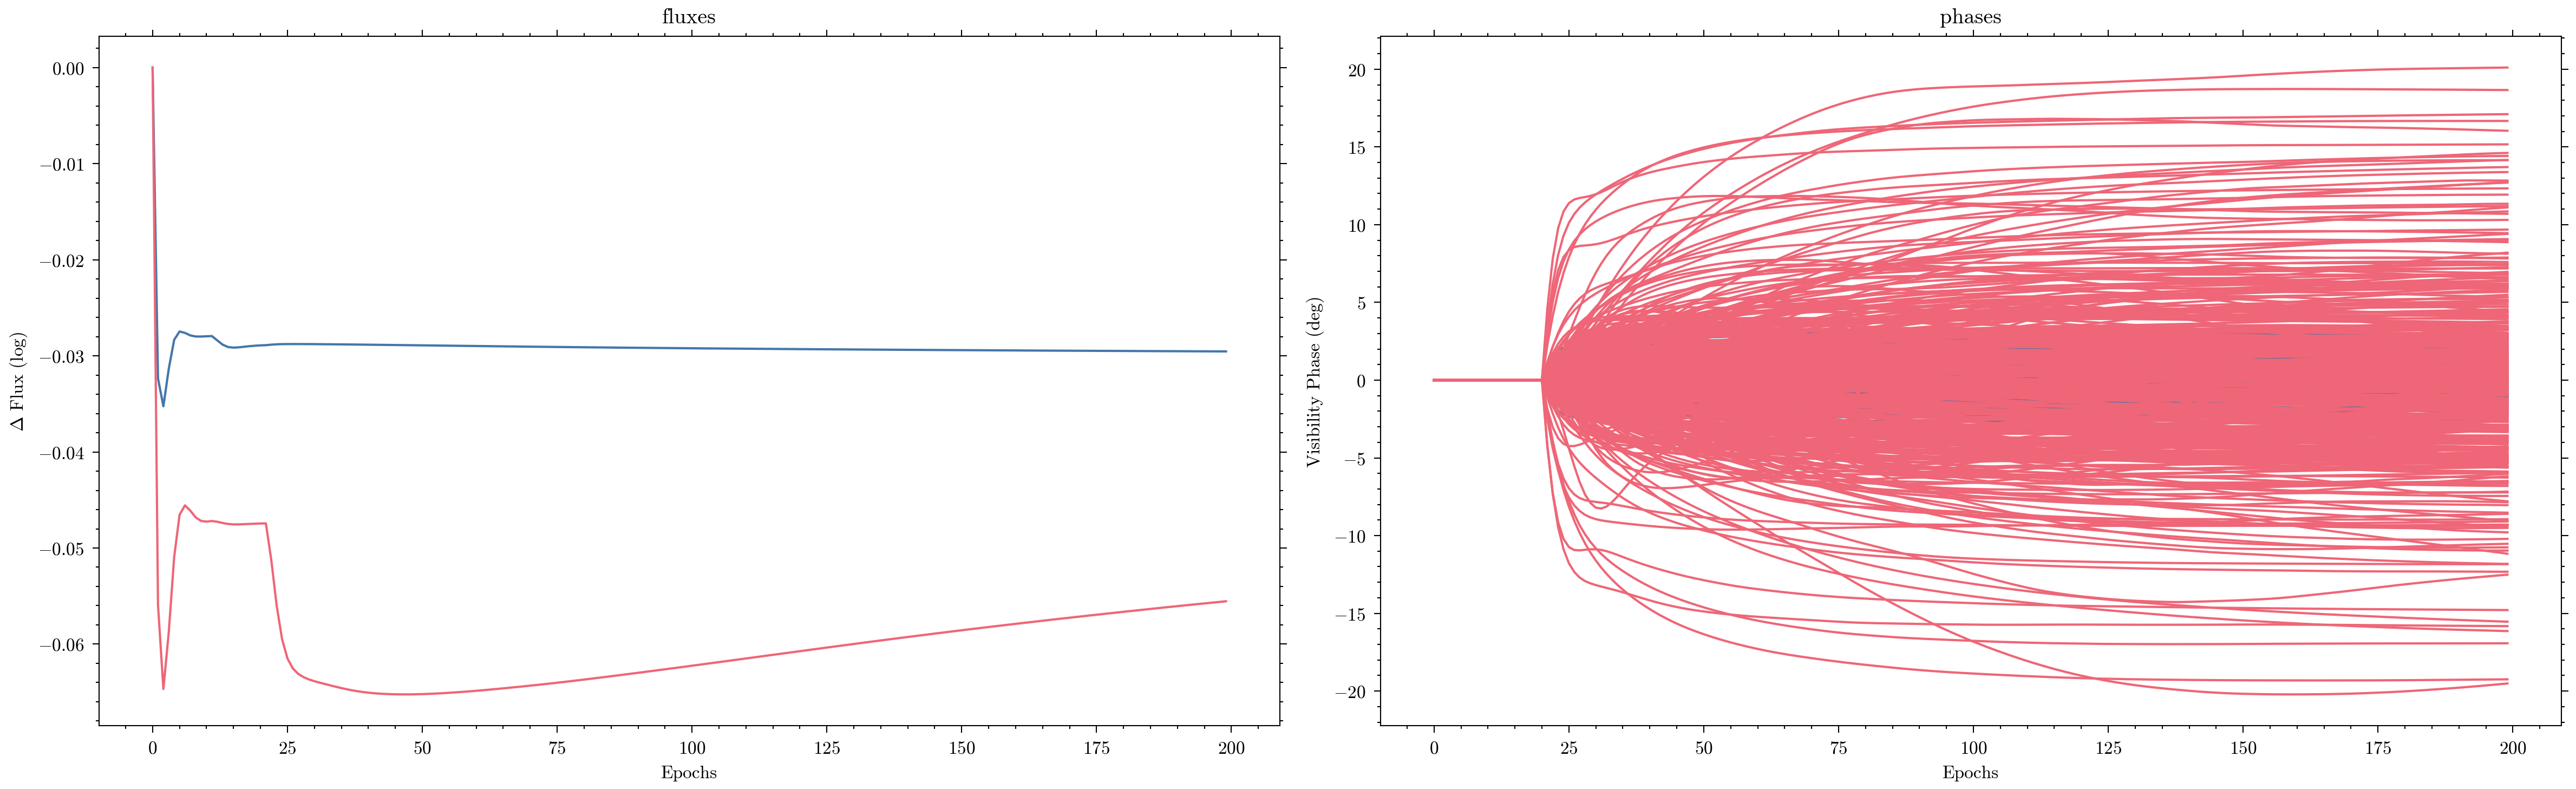

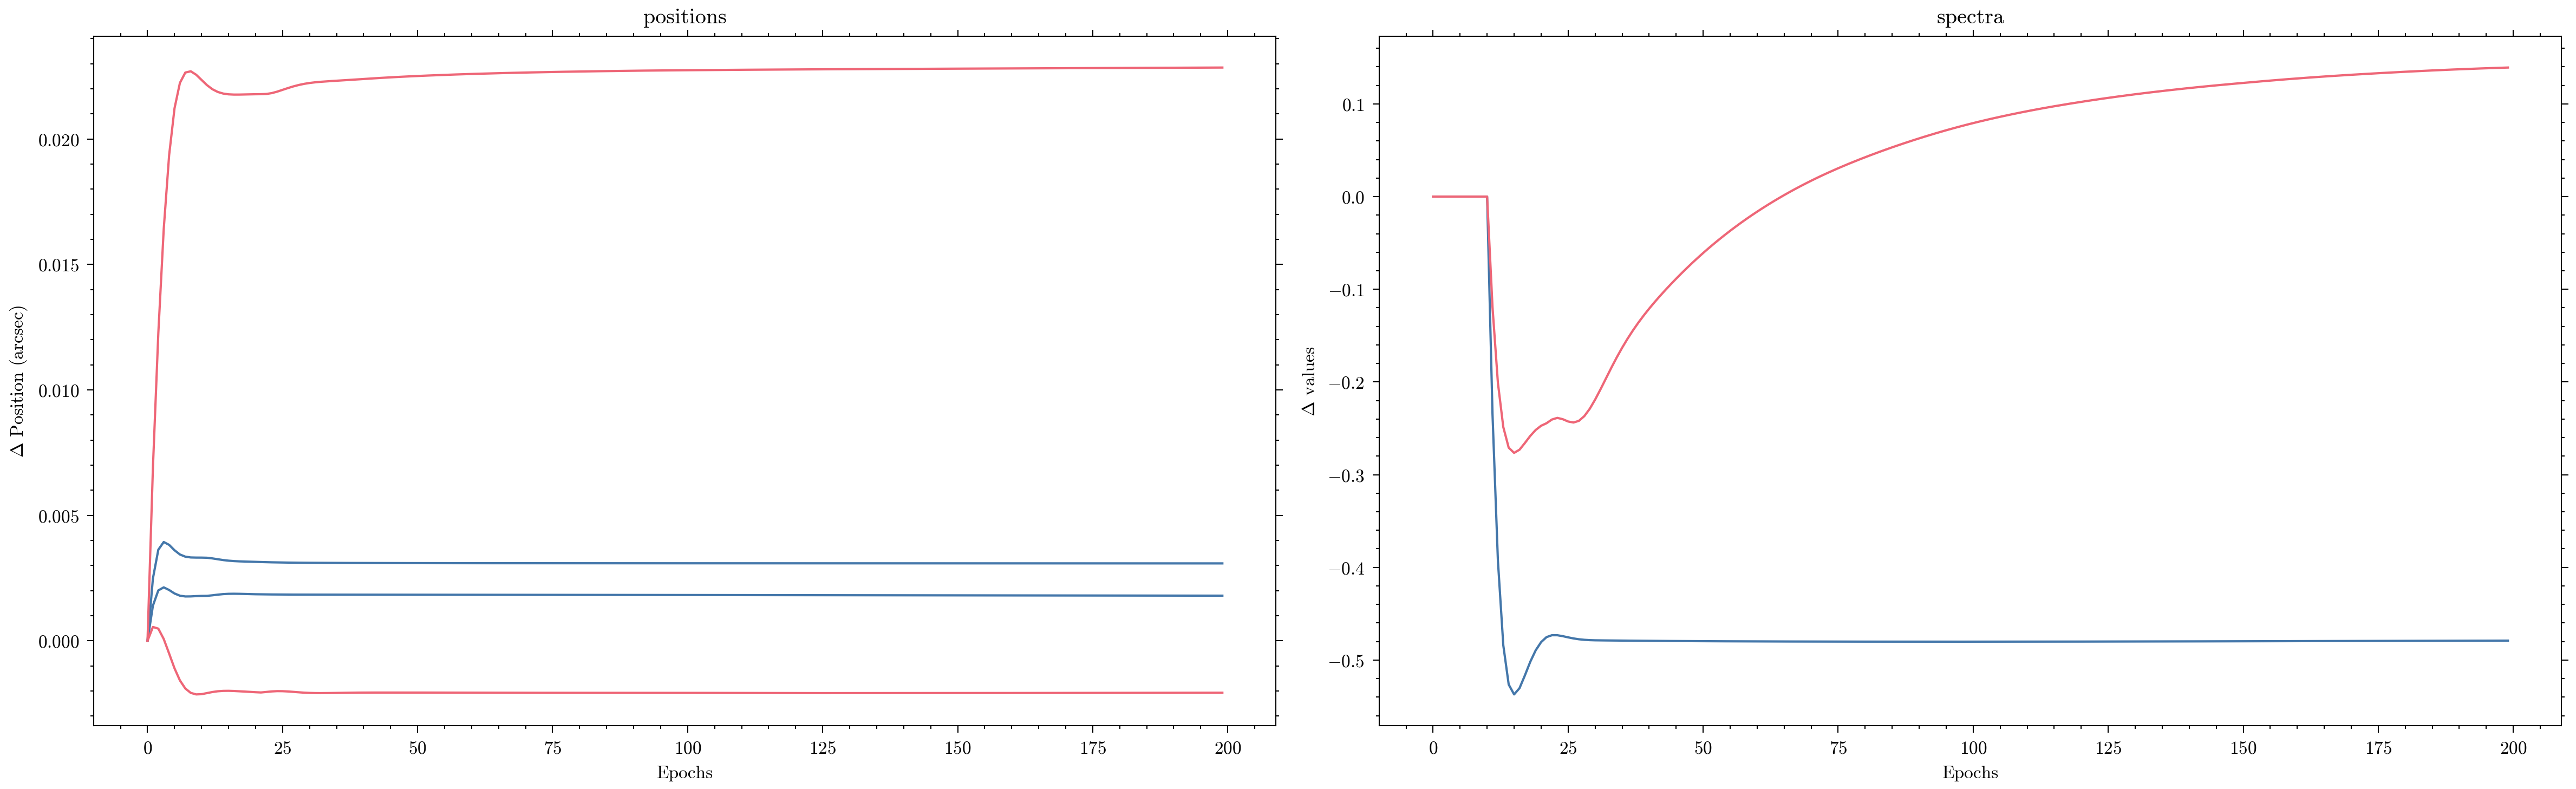

HD 228337


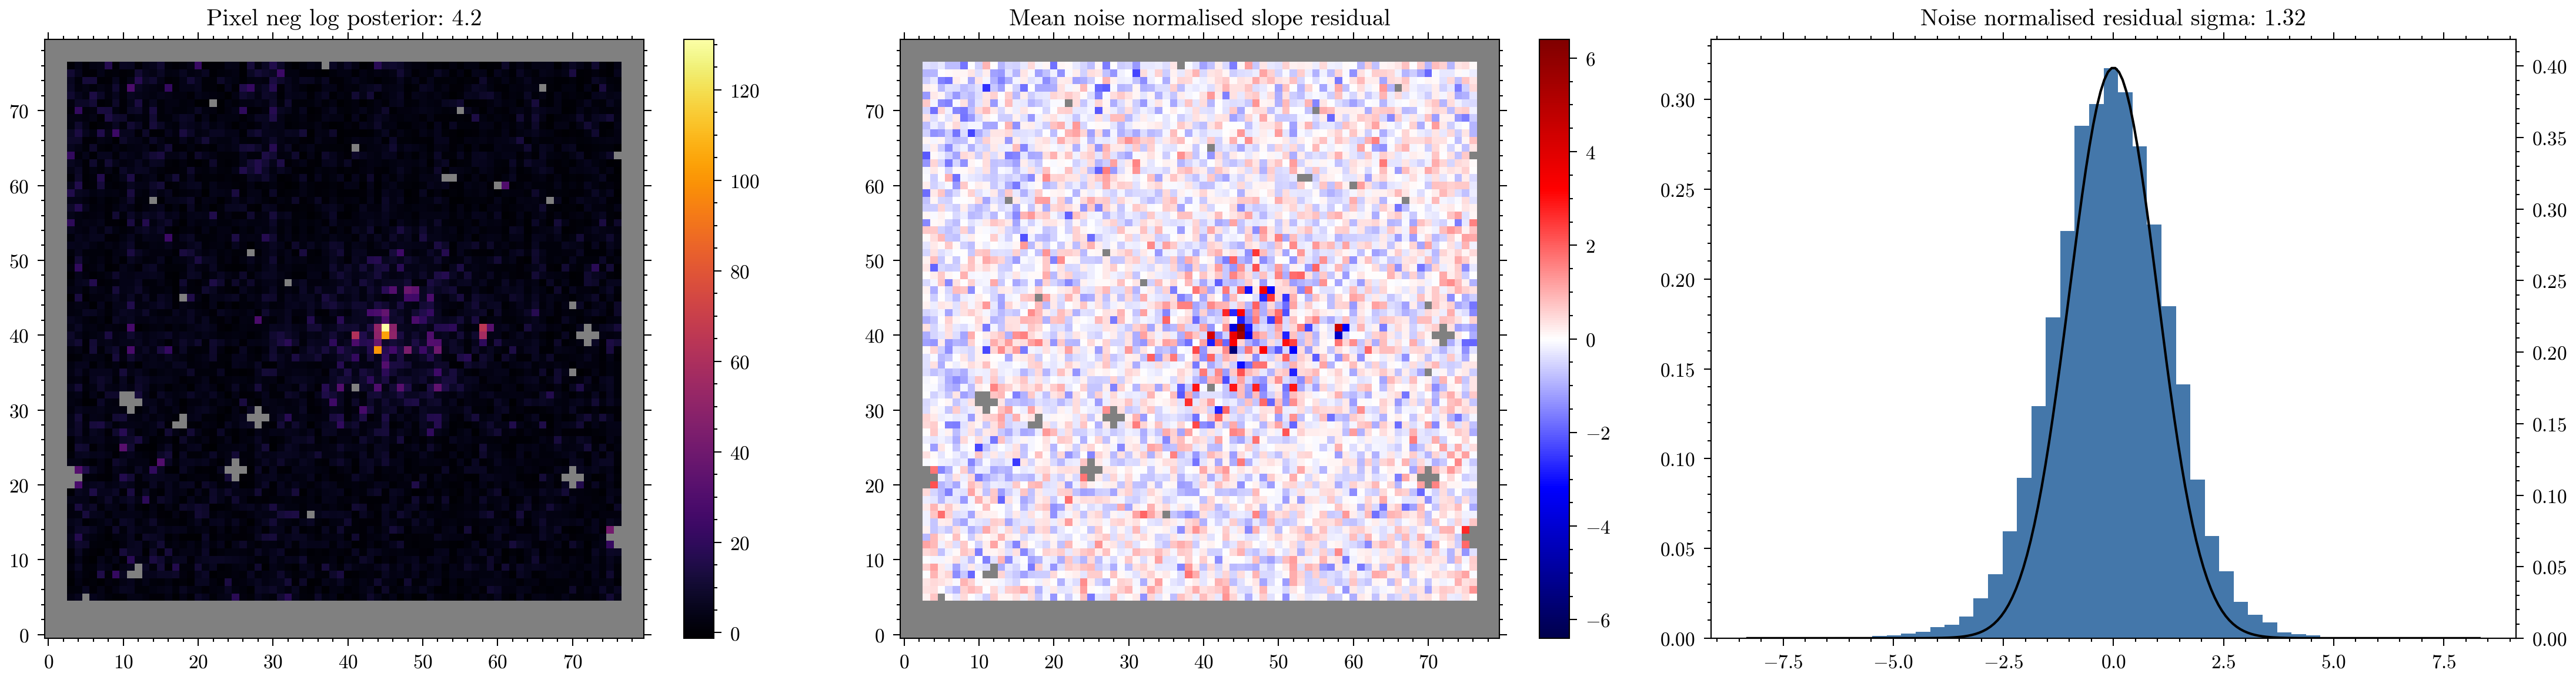

WR137


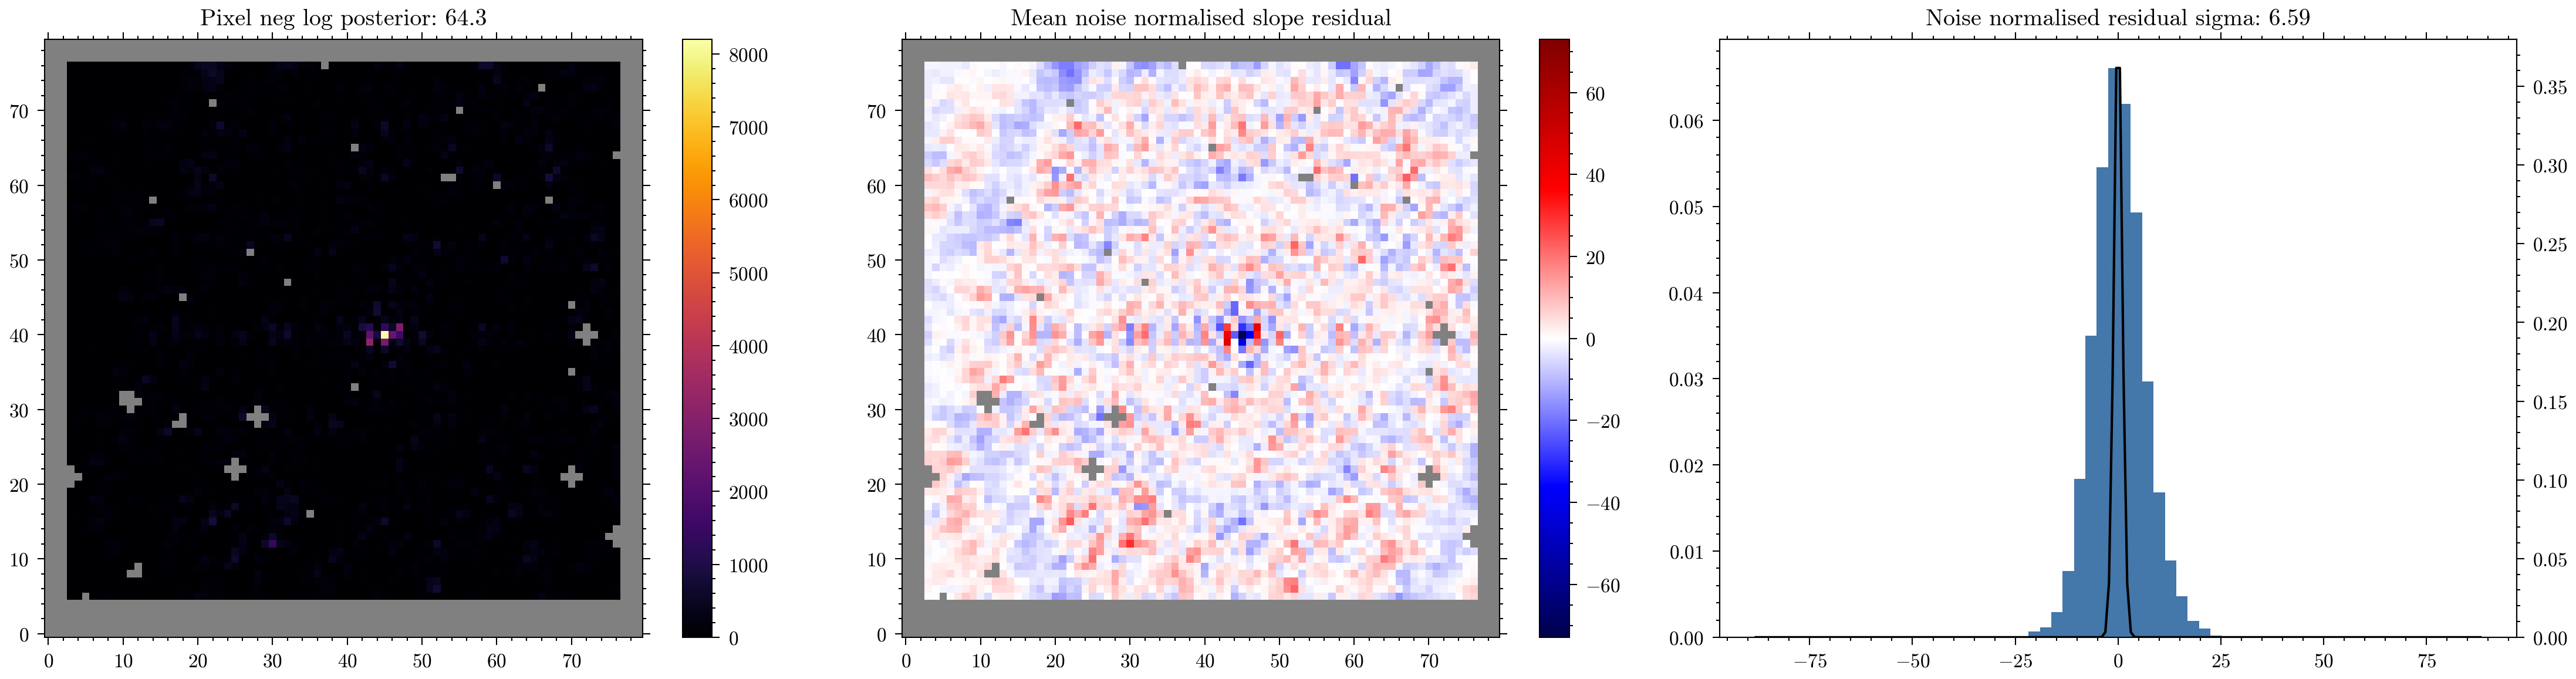

In [13]:
losses = np.array([v for v in result.losses.values()]).mean(0)

amigo.plotting.plot_losses(losses, start=int(0.8 * n_epoch))
amigo.plotting.plot(result.history)

# for exp in exposures:
for exp in exposures:
    print(exp.star)
    amigo.plotting.summarise_fit(result.model, exp)

In [14]:
# zdx.experimental.serialise(output_path + "firstbigrun.zdx", result.model.params)

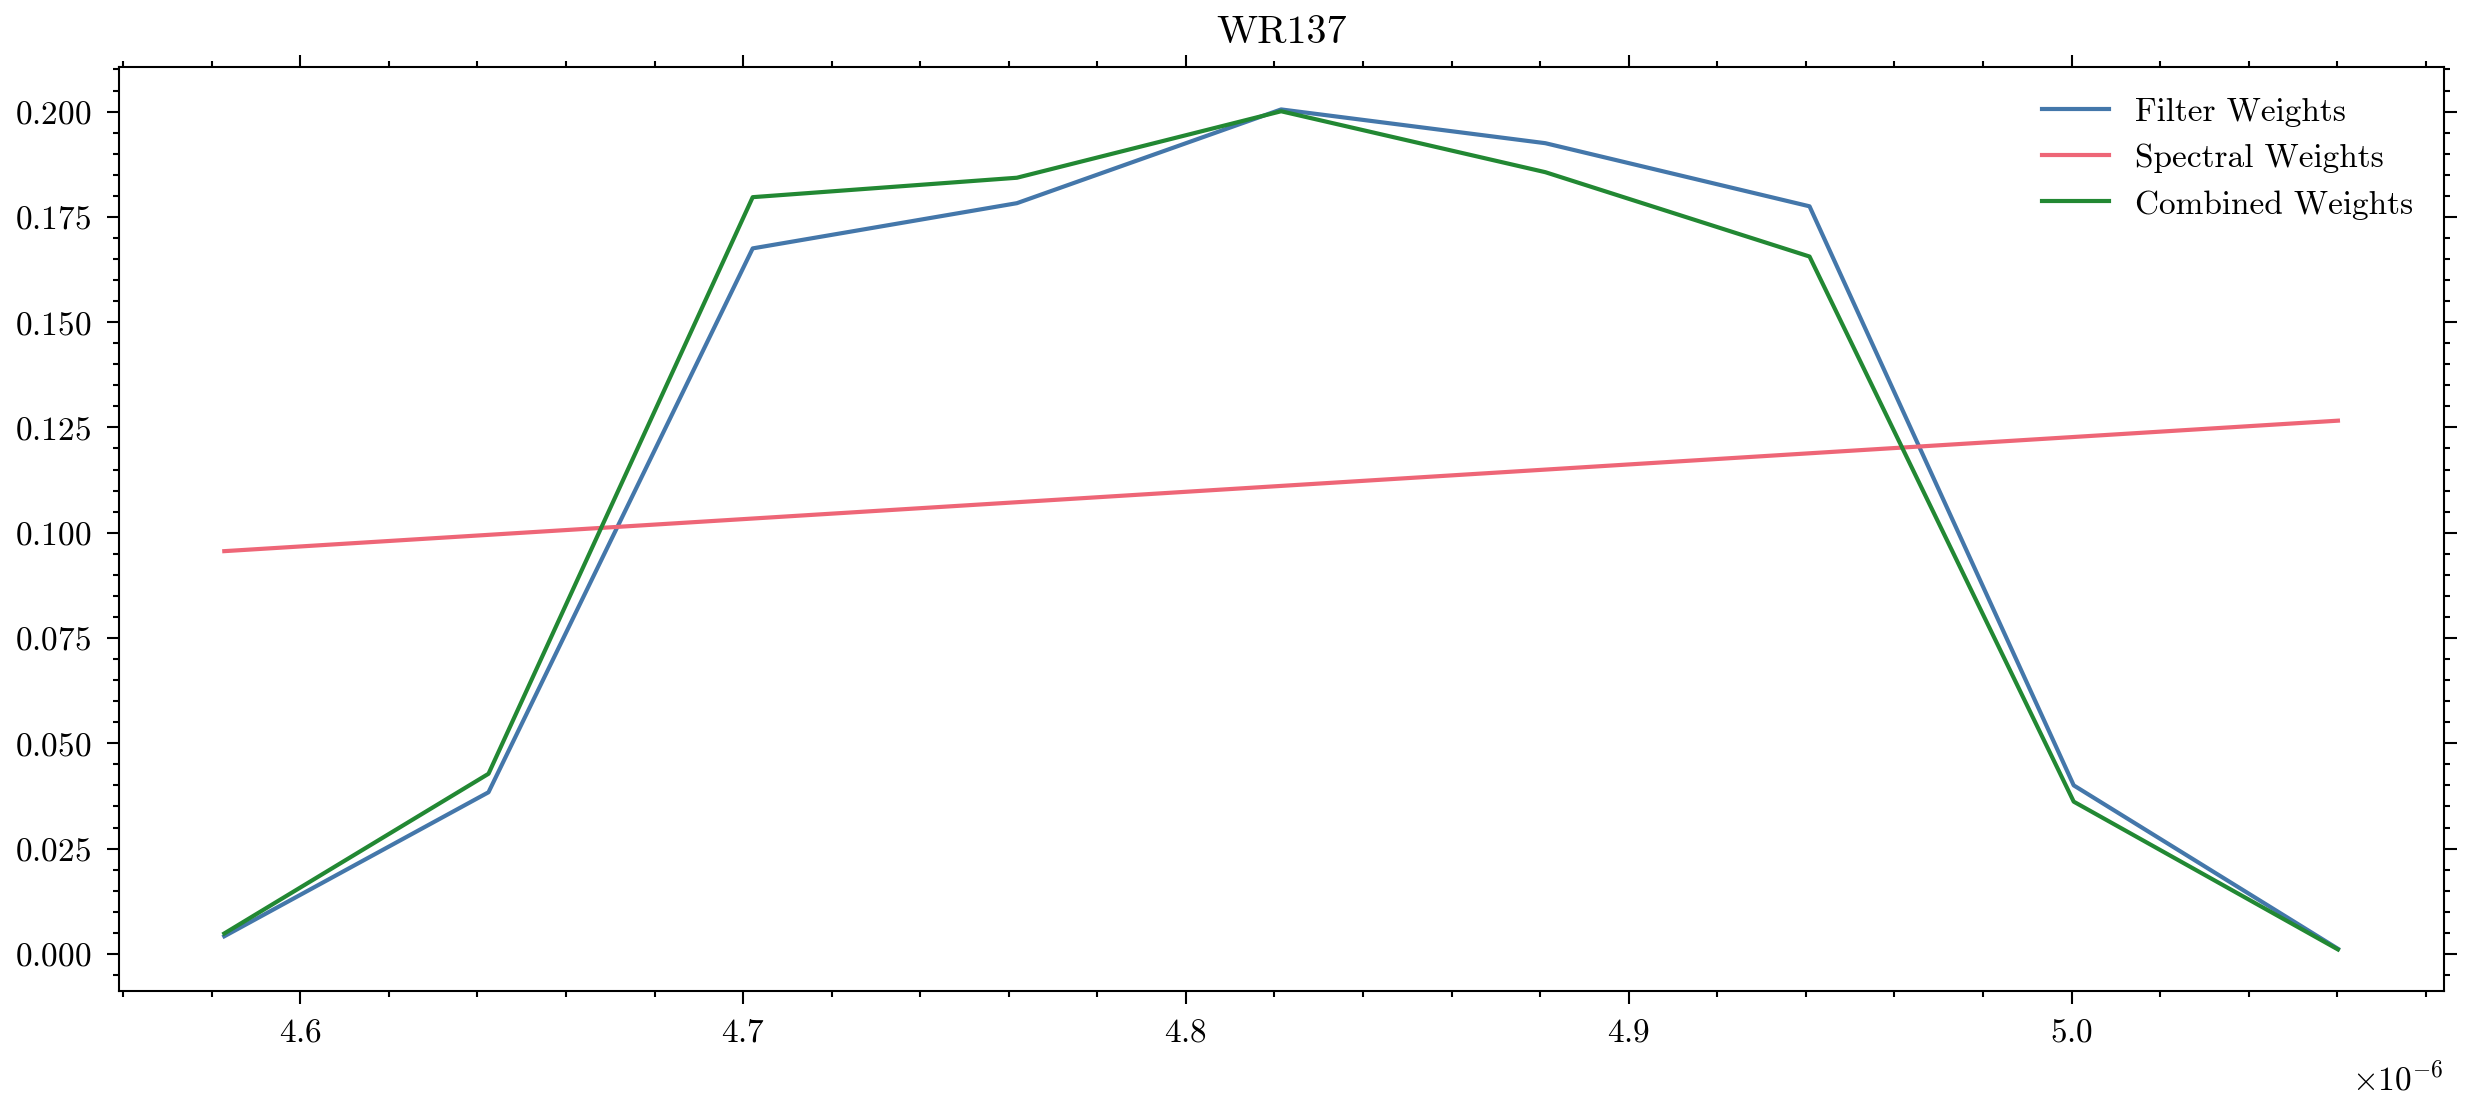

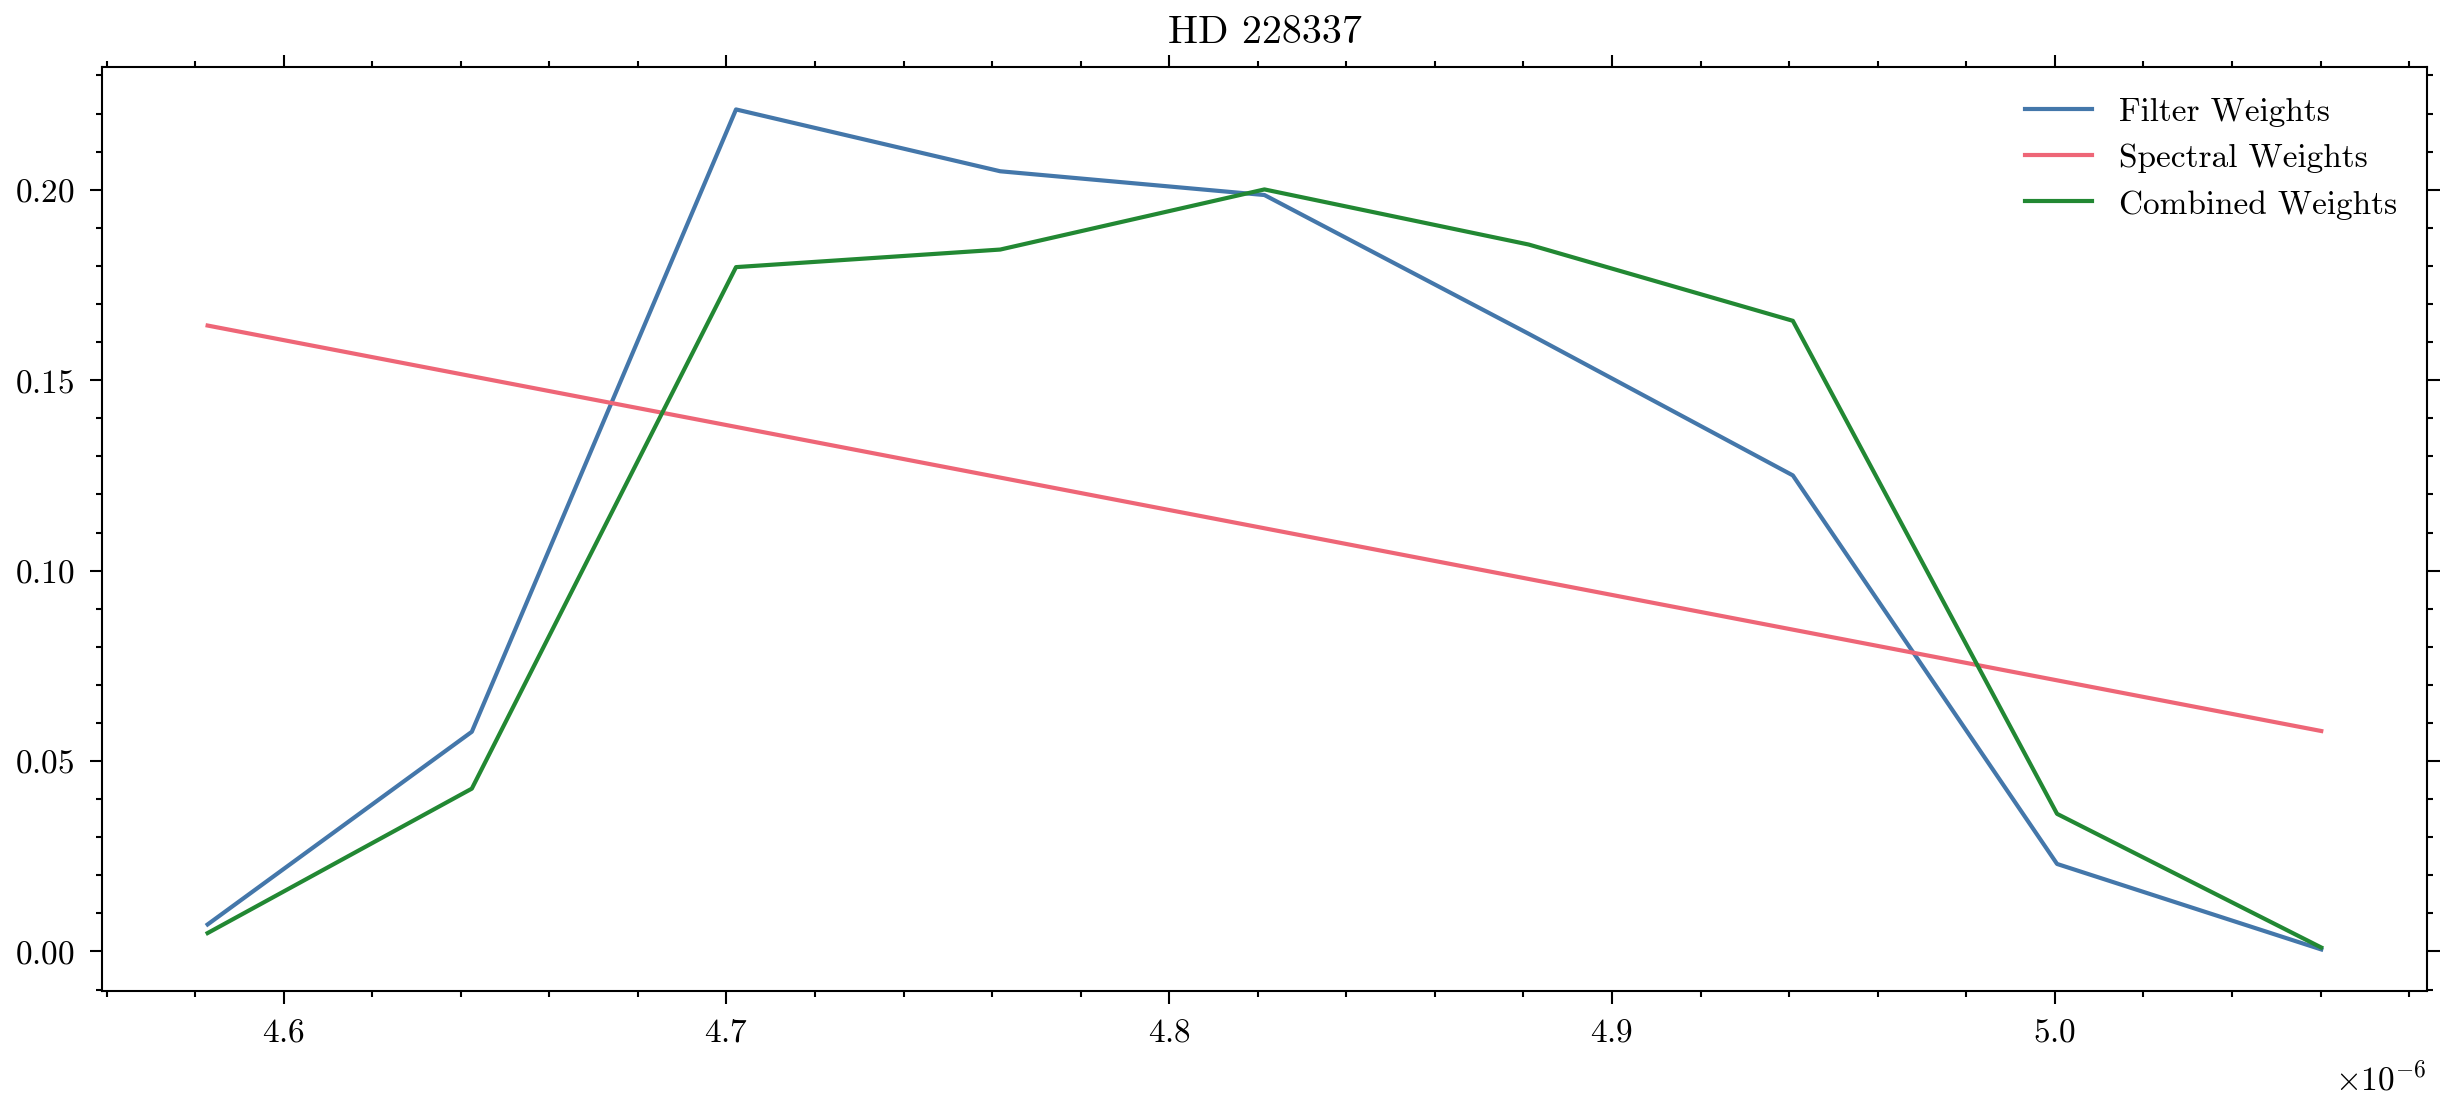

In [15]:
stars = list(set([exp.star for exp in exposures]))

for targ_star in stars:
    plt.figure(figsize=(10, 4))
    plt.title(f"{targ_star}")
    for key, spec in result.model.spectra.items():
        star, filt = key.split("_")

        if star != targ_star:
            continue

        wavels, filt_weights = model.filters[filt]
        xs = np.linspace(-1, 1, len(wavels), endpoint=True)
        spectra_slopes = 1 + spec * xs
        weights = filt_weights * spectra_slopes  # * wavels

        #
        filt_weights = filt_weights / filt_weights.sum()
        spectra_slopes = spectra_slopes / spectra_slopes.sum()
        weights = weights / weights.sum()

        plt.plot(wavels, weights, label="Filter Weights")
        plt.plot(wavels, spectra_slopes, label="Spectral Weights")
        plt.plot(wavels, filt_weights, label="Combined Weights")

    plt.legend()
    plt.show()

In [16]:
import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams


def get_proj_mat(fmat):
    """Get the projection matrix for a Fisher matrix"""
    eig_vals, eig_vecs = np.linalg.eig(-fmat)
    return (eig_vals.real**-0.5)[:, None] * eig_vecs.real.T


proj_mats = jtu.map(get_proj_mat, trainer.fishers)


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats, shapes = args

    # Project and add the parameters
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, params)
    model_params = jtu.map(lambda x, y: x + y, model_params, proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, shapes)
    model = model_params.inject(model)

    # Return the loss
    return -np.nanmean(exp.mv_zscore(model))


params = ["amplitudes", "phases", "fluxes", "spectra"]
final_model = result.model

args_out = {}
sols_out = {}
for exp in exposures:
    opt_params = {}
    fishers = {}
    shapes = {}
    for param in params:
        key = exp.map_param(param)
        shapes[key] = final_model.get(key).shape
        opt_params[key] = final_model.get(key).flatten()
        fishers[key] = trainer.fishers[f"{exp.key}.{param}"]

    shapes = ModelParams(shapes)
    model_params = ModelParams(opt_params)
    initial_params = jtu.map(lambda x: np.zeros_like(x), model_params)
    proj_mats = jtu.map(get_proj_mat, ModelParams(fishers))
    proj_mats = jtu.map(lambda x: np.where(np.isnan(x) | np.isinf(x), 0, x), proj_mats)

    args = (final_model, exp, model_params, proj_mats, shapes)
    args_out[exp.key] = args

    try:
        print("Initial loss:", fun(initial_params, args))
    except Exception as e:
        print(f"Skipped {exp.key}")
        continue
    solver = optx.BFGS(rtol=1e-6, atol=1e-6)
    sol = optx.minimise(fun, solver, initial_params, args, throw=False, max_steps=2048)
    sols_out[exp.key] = sol

    print("Final loss:", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

Initial loss: 5.255754289612039
Final loss: 5.253694247384668
560 212


Initial loss: 65.3435892868042
Final loss: 42.12837489713319
1363 735




In [17]:
spectra = {}
for key, args in args_out.items():
    proj_mats = args[3]
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, sols_out[key].value)
    model_params = jtu.map(lambda x, y: x + y, args[2], proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, args[4])
    final_model = model_params.inject(final_model)

    # Spectra is joint-fit so we take the mean
    exp = args[1]
    spec = model_params.params[exp.map_param("spectra")]
    spec_key = exp.get_key("spectra")
    if spec_key not in spectra:
        spectra[spec_key] = [spec]
    else:
        spectra[spec_key].append(spec)

spectra = jtu.map(
    lambda x: np.array(x).mean(), spectra, is_leaf=lambda x: isinstance(x, list)
)
final_model = final_model.set("spectra", spectra)

final_state = {}
for key, values in result.state.items():
    final_state[key] = final_model.get(key)

F480M Calibrator HD 228337 7


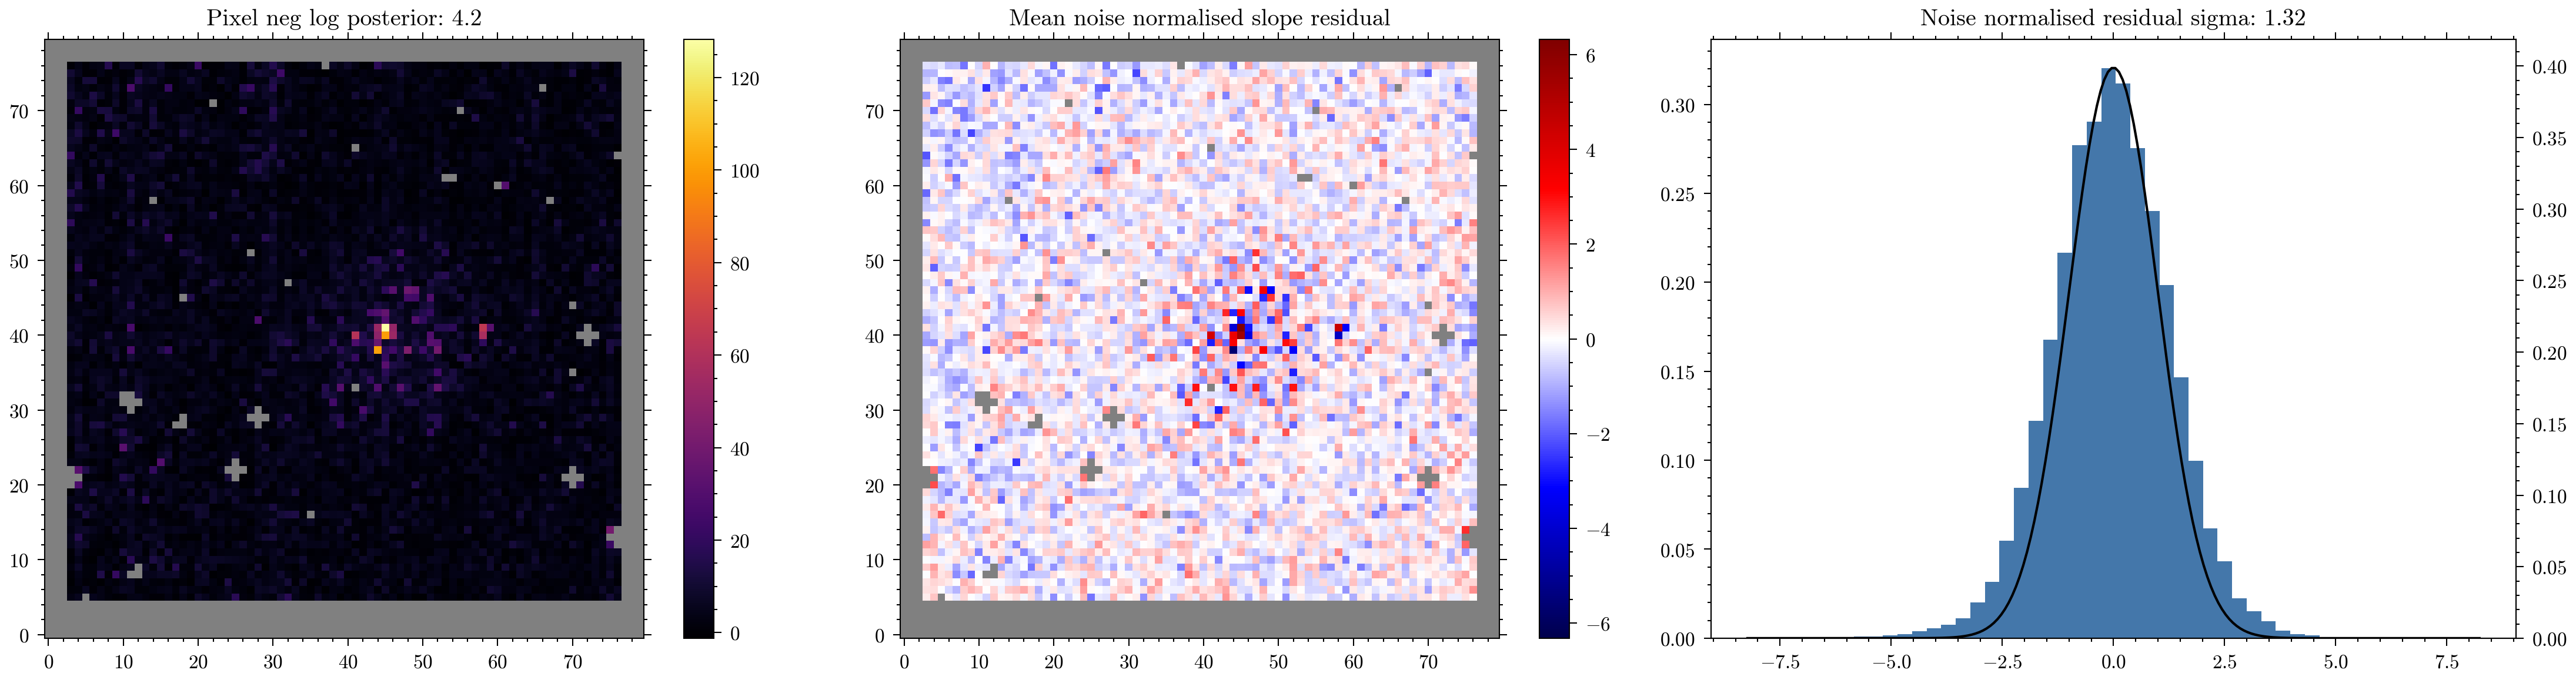

F480M Science WR137 4


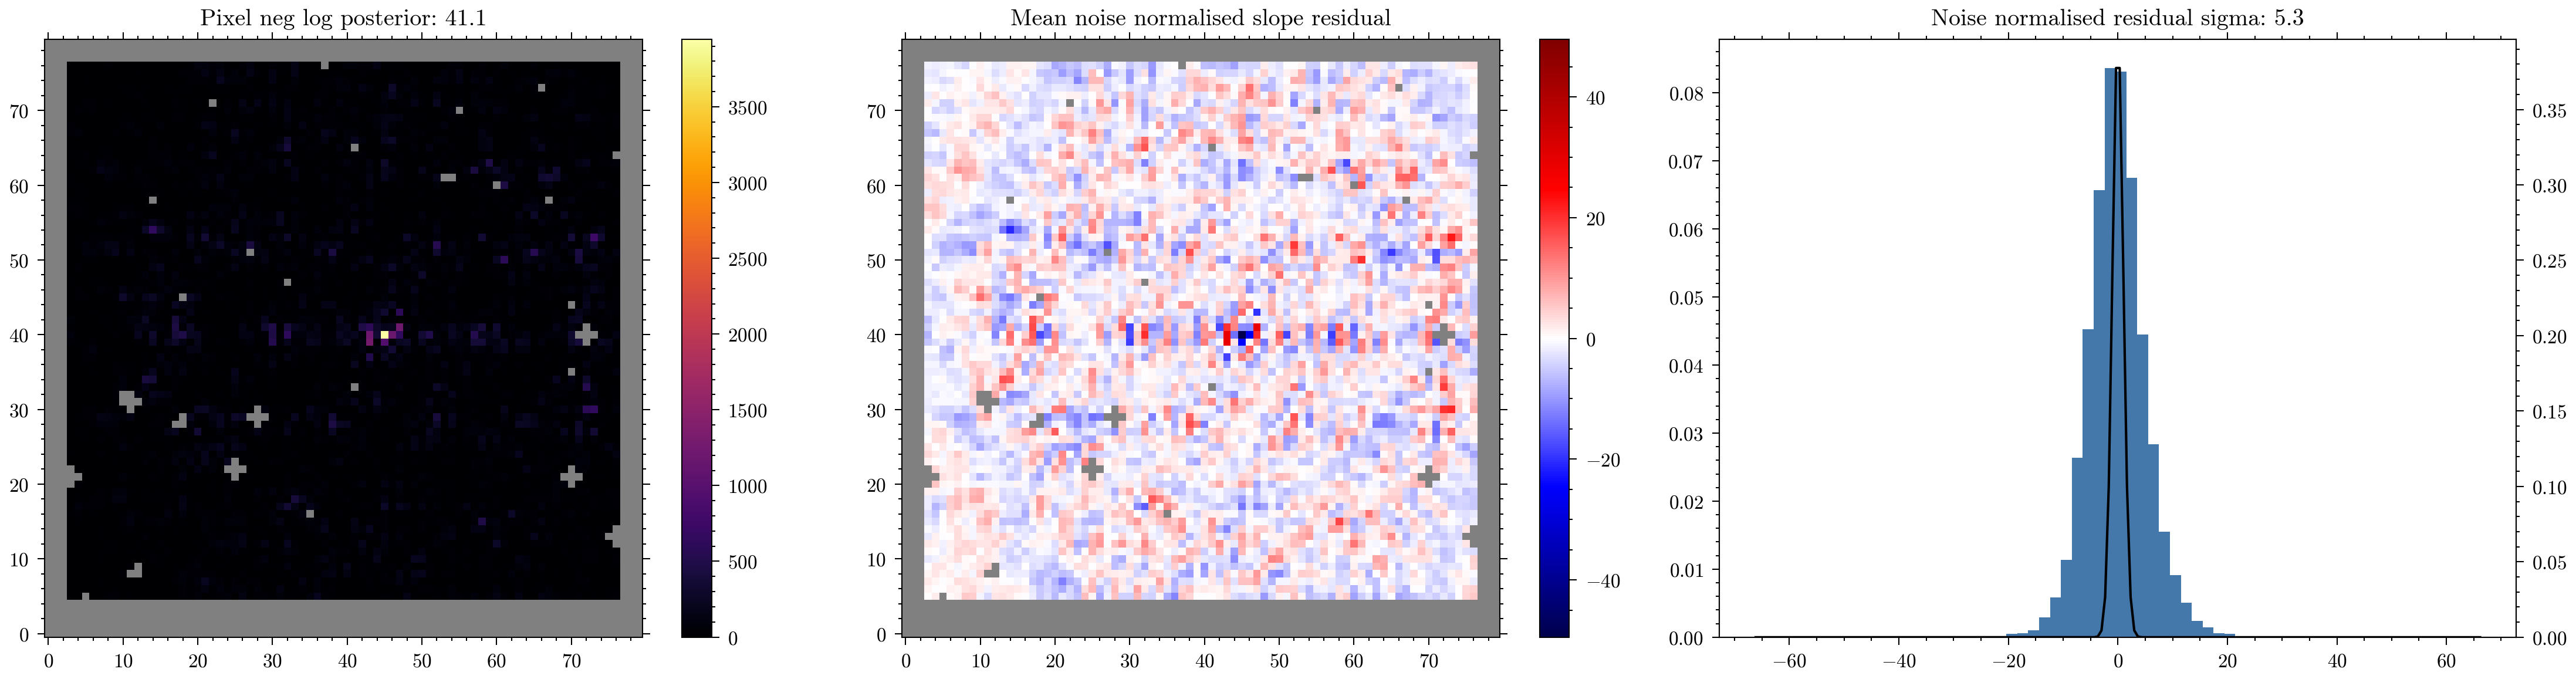

In [18]:
for filt in ["F380M", "F430M", "F480M"]:
    for exp in exposures:
        if exp.filter == filt:
            exp_type = "Calibrator" if exp.calibrator else "Science"
            print(exp.filter, exp_type, exp.star, exp.ngroups)
            amigo.plotting.summarise_fit(final_model, exp)

In [19]:
import jax.tree as jtu
from tqdm.notebook import tqdm
from amigo.fisher import FIM


fmats = {}
for exp in tqdm(exposures):
    loglike_fn = lambda model: -np.nansum(exp.loglike(model))
    params = [exp.map_param("amplitudes"), exp.map_param("phases")]
    fmat = FIM(final_model, params, loglike_fn, reduce_ram=True, batch_size=20)
    fmats[exp.get_key("phases")] = fmat

  0%|          | 0/2 [00:00<?, ?it/s]

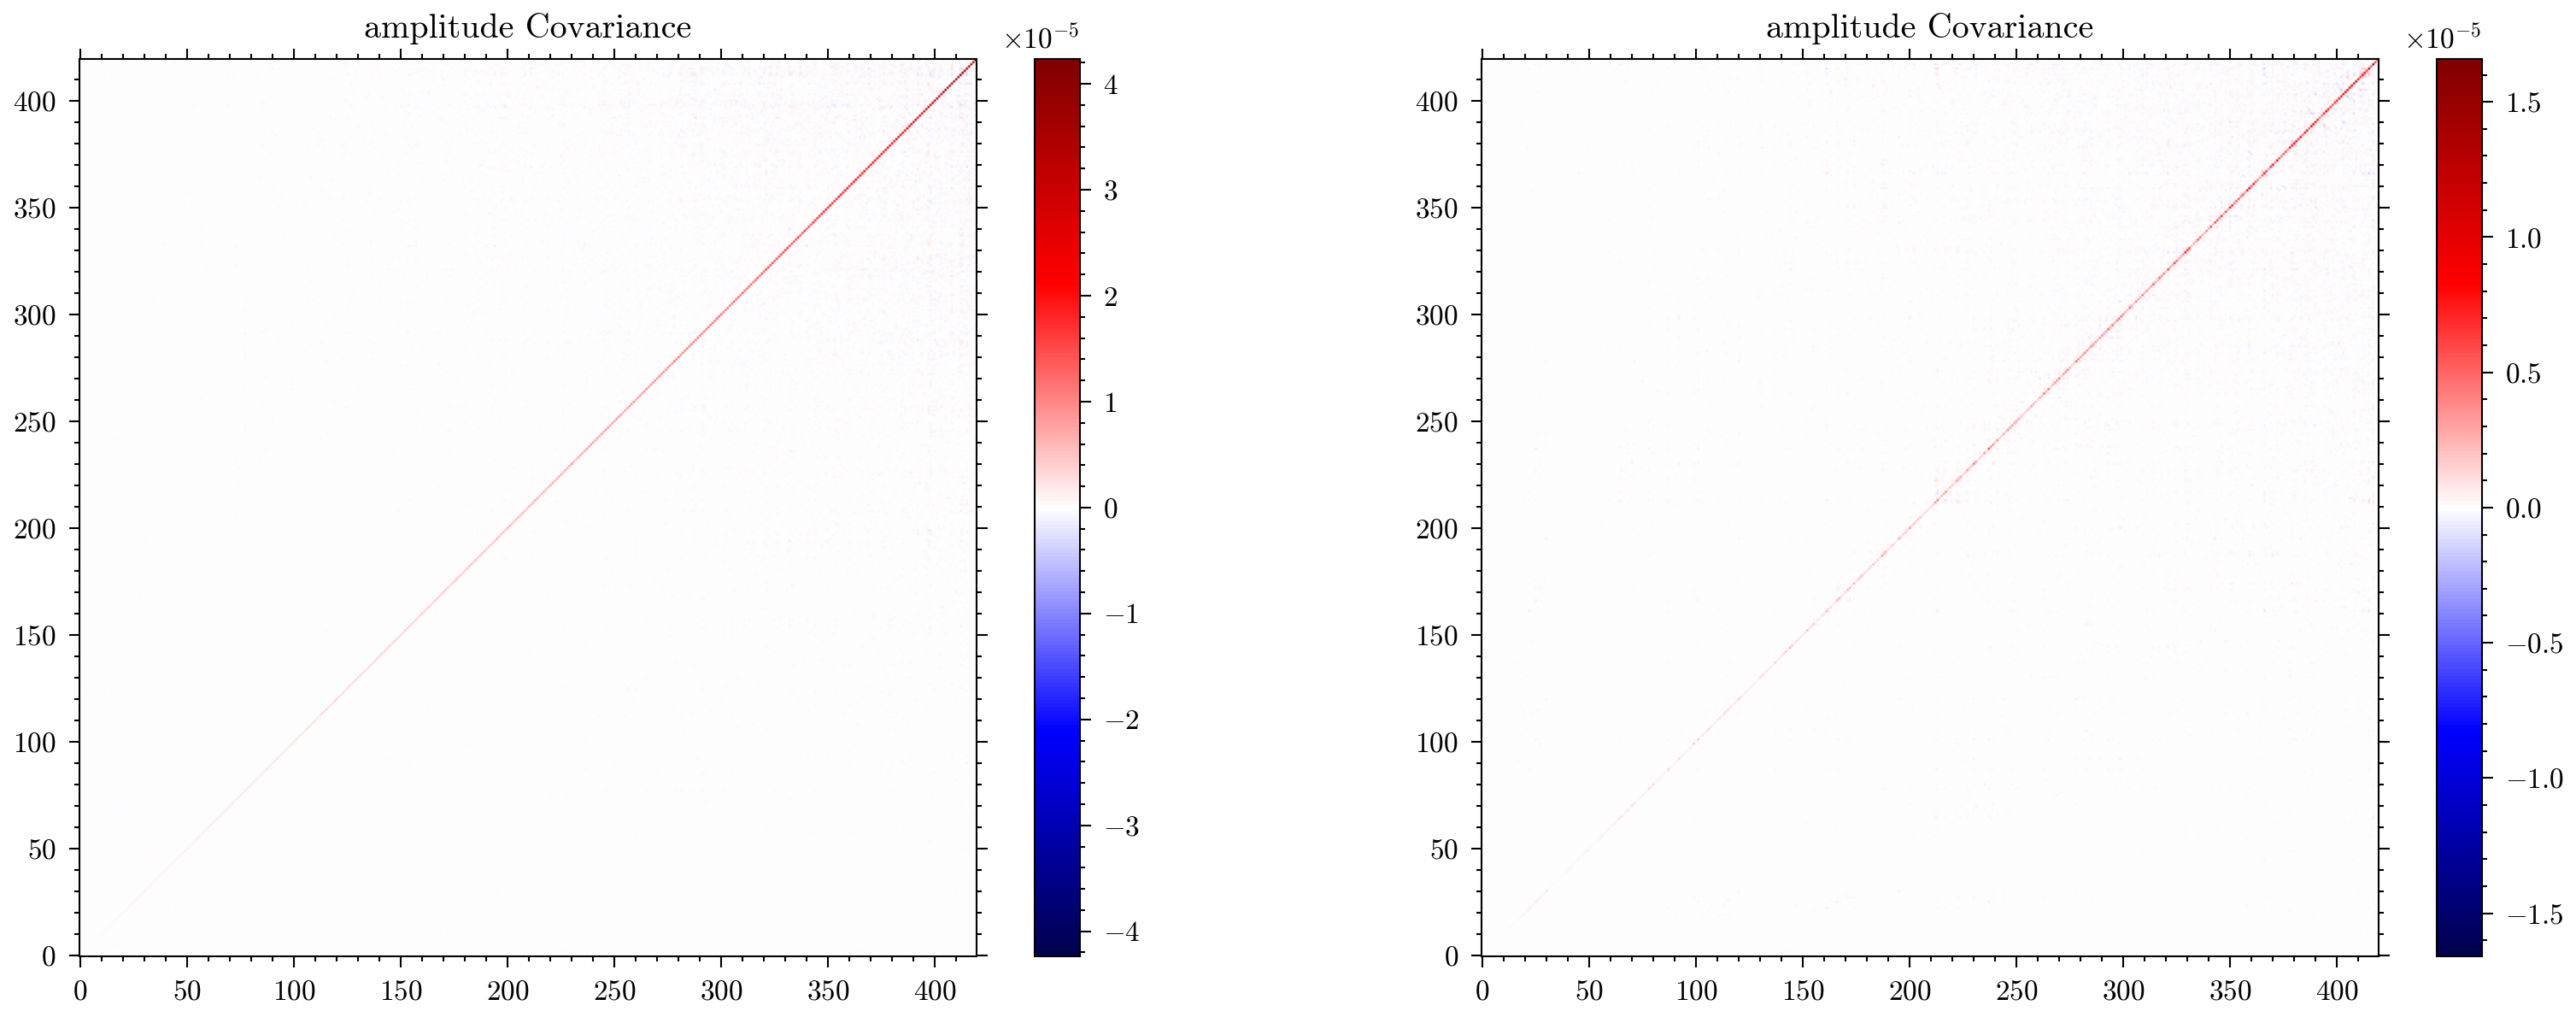

In [20]:
full_covs = jtu.map(lambda x: np.linalg.inv(x), fmats)

n = model.vis_model.n_basis
amp_covs = jtu.map(lambda x: x[:n, :n], full_covs)
phase_covs = jtu.map(lambda x: x[n:, n:], full_covs)

covs = {
    "amplitudes": amp_covs,
    "phases": phase_covs,
}

plt.figure(figsize=(20, 10))
for i, key in enumerate(amp_covs):
    if i > 5:
        break

    if i < 3:
        param = "amplitude"
        cov = amp_covs[key]
    else:
        param = "phase"
        cov = amp_covs[key]
    plt.subplot(2, 3, i + 1)
    plt.title(f"{param} Covariance")
    v = np.nanmax(np.abs(cov))
    plt.imshow(cov, seismic, vmin=-v, vmax=v)
    # plt.imshow(np.log10(np.abs(cov)), inferno)
    plt.colorbar()
plt.show()

In [21]:
fit_outputs = {
    "n_basis": final_model.vis_model.n_basis,
}

for exp in exposures:
    get_fn = lambda param: final_model.get(exp.map_param(param))
    fit_outputs[exp.key] = {
        "star": exp.star,
        "calibrator": exp.calibrator,
        "filter": exp.filter,
        "parang": exp.parang,
        "defocus": final_model.get(exp.map_param("defocus")),
        "n_basis": final_model.vis_model.n_basis,
        "fishers": fmats[exp.get_key("phases")],
        "amp_cov": amp_covs[exp.get_key("phases")],
        "phase_cov": phase_covs[exp.get_key("phases")],
        **{param: get_fn(param) for param in final_state.keys()},
    }

np.save(output_path + f"stares_latest_visibilities", fit_outputs, allow_pickle=True)